<table class="table table-bordered">
    <tr>
         <th style="text-align:center;"><font size="4"> <br/>IS217 Practice Notebook - Student Profile<br> </font></th>
    </tr>
</table>

## EDA and Clustering

**About the Dataset:**
This data about students was collected in a particular classroom. Below is the data dictionary :<br>

| Variable | Label | Type |
| --- | ----- | --- |
| Height | Height (cm) | Numerical (Ratio Scale)|
| Weight | Weight (kg) | Numerical (Ratio Scale)|
|Age | Age (in yrs, like 21.3) | Numerical (Ratio Scale)|
|HairLength | Length of hair (cm) | Numerical (Ratio Scale)|
|Sex |Sex (M/F)| Categorical (Nominal)|

**Instructions:**
 1. Read data from the given file, 'students.xlsx' into a Pandas DataFrame
 2. Using appropriate Python functions/libraries, answer the questions provided. Use this notebook for coding.

**The questions and results of the following Practice is based on Python 12.1.x code.**

### EDA

In [2]:
# !pip install openpyxl

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# To suppress warnings
# import warnings
# warnings.filterwarnings("ignore")

In [5]:
#read the excel file
#The data read must contain 87 rows and 5 columns
df = pd.read_excel('students.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Height      87 non-null     float64
 1   Weight      87 non-null     float64
 2   Age         87 non-null     float64
 3   HairLength  87 non-null     float64
 4   Sex         87 non-null     object 
dtypes: float64(4), object(1)
memory usage: 3.5+ KB


In [7]:
df.head()

,Height,Weight,Age,HairLength,Sex
0,169.0,60.0,21.2,10.0,M
1,174.0,73.0,26.8,12.0,M
2,163.0,58.0,21.0,22.0,F
3,163.0,55.0,20.0,18.0,F
4,174.0,67.0,22.3,15.0,M


In [9]:
df.nunique()

Height        35
Weight        38
Age           43
HairLength    29
Sex            2
dtype: int64

In [20]:
df['Sex'].value_counts()

Sex
M    45
F    42
Name: count, dtype: int64

####  Q1
<b>What is the mean age of the students in this dataset?</b> <br>
`round your answer to 2 decimal places`

a. 18.88 <br>
b. 22.96<br>
c. 23.22<br>
d. 22.61

In [23]:
round(df['Age'].mean(),2)

np.float64(22.96)

####  Q2
<b>What is the count of female students in this dataset?</b> <br>
This type of question (without multiple choice options) requires you to fill in the blanks in eLearn. 

In [25]:
df.groupby(['Sex']).count()

,Height,Weight,Age,HairLength
Sex,,,,
F,42,42,42,42
M,45,45,45,45


In [26]:
df['Sex'].value_counts()

Sex
M    45
F    42
Name: count, dtype: int64

#### Q3
**What is the age of the male student with maximum height?** <br>
a. 22.70 <br>
b. 23.20 <br>
c. 24.90 <br>
d. 21

In [28]:
df.iloc[df[df['Sex'] == 'M']['Height'].idxmax()]

Height        185.0
Weight         68.0
Age            24.9
HairLength      5.0
Sex               M
Name: 42, dtype: object

#### Q4
<b>Locate the extreme outlier observation in the dataset. What is the outlier variable and value?</b> <br>

a. Age, 26.8 <br>
b. HairLength, 60 <br>
c. Weight, 80 <br>
d. Age, 53 <br>

`Hint: One option could be to use box plots to identify the variable. Then use the idxmax() function`

<Axes: >

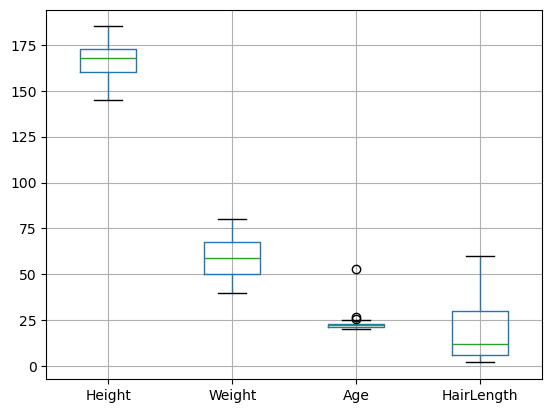

In [34]:
# Check with box plots first
df.boxplot()

In [35]:
df['Age'].max()

53.0

### Clustering

#### Q5
<b>Remove the extreme outlier observation identified in the previous question from the dataframe (note: you should remove only one observation). Now, transform the 4 numeric variables in the dataset using log transformation. What is the mean of the Log(Weight) variable. Round the answer to 2 decimal places.</b> <br>

a.	5.12 <br>
b.	58.68 <br>
c.	4.06 <br>
d.	4.09 <br>

`Hint:` <br>
`Create 4 new columns in the DataFrame which are the log transformed values of the original columns. To do this apply the np.log() function on the original column of each of the required variables`. <br>
`Note : Plot a histogram of the original variables to understand why is the transformation being done`

In [36]:
#df['Age'].idxmax() # to check the index again if you wish
df2 = df.drop(df['Age'].idxmax())

In [37]:
df2['log_ht'] = np.log(df2['Height'])
df2['log_wt'] = np.log(df2['Weight'])
df2['log_age'] = np.log(df2['Age'])
df2['log_hairlen'] = np.log(df2['HairLength'])

df2

,Height,Weight,Age,HairLength,Sex,log_ht,log_wt,log_age,log_hairlen
0,169.0,60.0,21.2,10.0,M,5.129899,4.094345,3.054001,2.302585
1,174.0,73.0,26.8,12.0,M,5.159055,4.290459,3.288402,2.484907
2,163.0,58.0,21.0,22.0,F,5.093750,4.060443,3.044522,3.091042
3,163.0,55.0,20.0,18.0,F,5.093750,4.007333,2.995732,2.890372
4,174.0,67.0,22.3,15.0,M,5.159055,4.204693,3.104587,2.708050
...,...,...,...,...,...,...,...,...,...
82,175.0,63.0,23.2,10.0,M,5.164786,4.143135,3.144152,2.302585
83,163.0,44.0,21.0,20.0,F,5.093750,3.784190,3.044522,2.995732
84,152.0,47.0,21.0,20.0,F,5.023881,3.850148,3.044522,2.995732
85,174.0,48.0,21.0,25.0,F,5.159055,3.871201,3.044522,3.218876


#### Q6
<b>In order to perform k means clustering using the 4 transformed variables above, use Elbow method and choose 2 suitable values of k from the answer options. Consider K ranging from 2 to 7 (Choose the 2 correct answer options)</b> <br>
Note: For consistency, use random_state = 0. <br>

a. 7 <br>
b. 2 <br>
c. 4 <br>
d. 6 <br>

`Hint: run a for loop in range(2,8) for different values of k. Inside the for loop, fit the KMeans model for the data with 4 transformed variables.
The 'kmeans.inertia_' variable, has the SSE for the clustering.
Plot this SSE on y axis and the k on x axis.  This gives you the Elbow plot. Now find the appropriate k`.

In [40]:
from sklearn.cluster import KMeans

In [38]:
df3 = df2.iloc[:,5:9]
#df3 = df2[['log_ht', 'log_wt', 'log_age','log_hairlen']]
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86 entries, 0 to 86
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   log_ht       86 non-null     float64
 1   log_wt       86 non-null     float64
 2   log_age      86 non-null     float64
 3   log_hairlen  86 non-null     float64
dtypes: float64(4)
memory usage: 3.4 KB


In [41]:
SSE = []
k = range(2,8)
for i in k:
    model_i = KMeans(n_clusters = i, random_state=0)
    model_i.fit(df3)
    SSE.append(model_i.inertia_)

SSE

C:\Users\Durga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Durga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Durga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Durga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

[14.322196098337521,
 7.98720316297677,
 5.193610901559582,
 3.983419728207056,
 2.997948573393057,
 2.598028239747068]

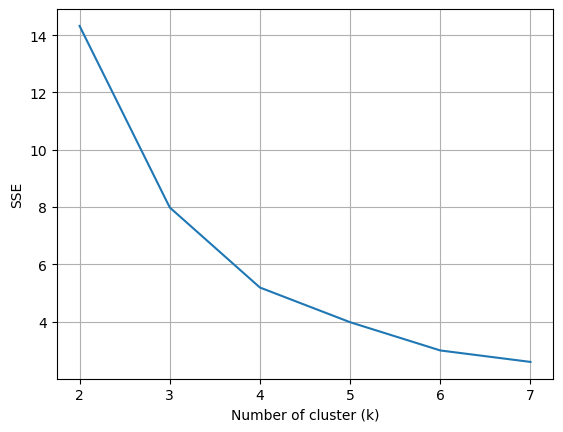

In [42]:
plt.plot(k, SSE)
plt.xlabel("Number of cluster (k)")
plt.ylabel("SSE")
plt.grid(True)
plt.show()

#### Q7
<b>For questions that follow, perform k means clustering for k = 4. Set parameter *random_state=0* in the *KMeans* function. Append a new column 'labels' to the data showing the assigned cluster labels. What is the mean HairLength of the data points in the cluster with 24 observations? Round the answer to 2 decimal places.</b> <br>


In [43]:
model_4 = KMeans(n_clusters = 4, random_state=0)
model_4.fit(df3)

C:\Users\Durga\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [44]:
# Append new colun to the data showing the assigned cluster labels. 
# Note that question asked for mean HairLength. This variable is only available in either df or df2, not in df3.
# You may add the labels to either df or df2
df2['cluster'] = model_4.labels_
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 86 entries, 0 to 86
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Height       86 non-null     float64
 1   Weight       86 non-null     float64
 2   Age          86 non-null     float64
 3   HairLength   86 non-null     float64
 4   Sex          86 non-null     object 
 5   log_ht       86 non-null     float64
 6   log_wt       86 non-null     float64
 7   log_age      86 non-null     float64
 8   log_hairlen  86 non-null     float64
 9   cluster      86 non-null     int32  
dtypes: float64(8), int32(1), object(1)
memory usage: 7.1+ KB


#### Q8
<b>What is the SSE for this clustering solution? Round the answer to 2 decimal places.</b> <br>

#### Q9

<b>What is the percentage of males in the cluster with 26 observations?</b> <br>
a.	51.16% <br>
b.	 0% <br>
c.	100% <br>
d.	95% <br>


#### Q 10

**What is the percentage of males in the cluster with 24 observations?** <br>
a.	0% <br>
b.	100% <br>
c.	5% <br>
d.	88%